# Feature engineering - VNExpress News Dataset

Việc chúng ta mã hóa các văn bản, ta chỉ mới sử dụng các trường văn bản, tiếp sau đây
chúng ta thực hiện việc trích xuất các đặc trưng ở các trường còn lại

Notebook này thực hiện việc trích xuất đặc trưng ở các mục:

1. Metadata
2. Thời gian
3. Author
4. Visualization những đặc trưng đã trích xuất

Load dữ liệu được encode từ trước

In [2]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc dữ liệu
df = pd.read_csv(r"..\\data\\vnexpress_clean_data.csv")

# Gộp text
df["full_text"] = (
    df["title"].fillna("") + " " +
    df["description"].fillna("") + " " +
    df["content"].fillna("")
)

# Load vectorizer và encode
with open("..\\data\\vietnamese-stopwords.txt", encoding="utf-8") as f:
    vietnamese_stopwords = f.read().splitlines()

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    token_pattern=r"(?u)\b[a-zA-ZÀ-ỹ_]+\b",
    stop_words=vietnamese_stopwords
)

X_text = vectorizer.fit_transform(df["full_text"])
print("TF-IDF matrix shape:", X_text.shape)

# Label encoding
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["group"])

print(f"Classes: {label_encoder.classes_}")
print(f"Target distribution:\n{np.bincount(y)}")

c:\Users\nguye\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_extraction\text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['a', 'bao', 'bay', 'biến', 'biệt', 'bây', 'bõm', 'bảo', 'bất', 'bẩy', 'bập', 'bắt', 'bội', 'chao', 'chi', 'chia', 'chu', 'chui', 'chuẩn', 'chà', 'chành', 'chí', 'chót', 'chùn', 'chăn', 'chũn', 'chưng', 'chạnh', 'chả', 'chầm', 'chầy', 'chập', 'chắn', 'chẳng', 'chết', 'chốc', 'chừ', 'chừng', 'coi', 'cu', 'cá', 'câu', 'cóc', 'công', 'cạnh', 'cảm', 'cầu', 'cật', 'cắt', 'cổ', 'cụ', 'cục', 'cực', 'da', 'dà', 'dĩ', 'dưng', 'dần', 'dầu', 'dịp', 'dở', 'dụng', 'gian', 'giá', 'giác', 'giời', 'ha', 'hiện', 'hoàn', 'hèn', 'hình', 'hô', 'hầu', 'hậu', 'hẳn', 'hồ', 'hỗ', 'hội', 'hợp', 'hự', 'khói', 'khô', 'khăn', 'khắc', 'khẳng', 'kia', 'kiện', 'kê', 'kì', 'kìa', 'kỳ', 'lai', 'le', 'liên', 'liệt', 'loạt', 'luận', 'luật', 'luốt', 'lình', 'lí', 'lô', 'lý', 'lập', 'lẽ', 'lị', '

TF-IDF matrix shape: (1182, 5000)
Classes: ['Giải trí' 'Khác' 'Sức khỏe']
Target distribution:
[559  20 603]


1. Trích xuất features từ Metadata

In [3]:
# Độ dài text
df["title_length"] = df["title"].fillna("").str.len()
df["description_length"] = df["description"].fillna("").str.len()
df["content_length"] = df["content"].fillna("").str.len()
df["full_text_length"] = df["full_text"].str.len()

print("\n✓ Text length features:")
print(df[["title_length", "description_length", "content_length", "full_text_length"]].describe())

# Số lượng từ
df["title_words"] = df["title"].fillna("").str.split().str.len()
df["description_words"] = df["description"].fillna("").str.split().str.len()
df["content_words"] = df["content"].fillna("").str.split().str.len()
df["full_text_words"] = df["full_text"].str.split().str.len()

print("\n✓ Word count features:")
print(df[["title_words", "description_words", "content_words", "full_text_words"]].describe())

# Số lượng câu (phân tách bằng dấu chấm)
df["title_sentences"] = df["title"].fillna("").str.count(r"[.!?]") + 1
df["content_sentences"] = df["content"].fillna("").str.count(r"[.!?]") + 1

print("\n✓ Sentence count features:")
print(df[["title_sentences", "content_sentences"]].describe())

# Số lượng số (digits)
df["title_digits"] = df["title"].fillna("").str.count(r"\d")
df["content_digits"] = df["content"].fillna("").str.count(r"\d")

print("\n✓ Digit count features:")
print(df[["title_digits", "content_digits"]].describe())

# Số tags
df["num_tags"] = df["tags"].fillna("").str.split(",").str.len()
df.loc[df["tags"].isna(), "num_tags"] = 0

print("\n✓ Tags features:")
print(df["num_tags"].describe())

# Số lượng comment
print("\n✓ Comments feature:")
print(df["nums_of_comments"].describe())


✓ Text length features:
       title_length  description_length  content_length  full_text_length
count    1182.00000         1182.000000     1182.000000       1182.000000
mean       44.91709          134.857868     3282.681895       3464.456853
std        10.85295           24.400555     1582.092828       1583.681371
min        15.00000            0.000000      986.000000       1124.000000
25%        38.00000          119.000000     2212.000000       2438.000000
50%        45.00000          132.000000     2841.000000       3028.000000
75%        52.00000          149.000000     3902.000000       4078.000000
max        74.00000          217.000000    11442.000000      11610.000000

✓ Word count features:
       title_words  description_words  content_words  full_text_words
count  1182.000000        1182.000000    1182.000000      1182.000000
mean     10.276650          29.453469     703.540609       743.270728
std       2.449582           5.508283     339.496499       339.903771
min  

* `content_length` gần bằng `full_text_length` -> nội dung chi phối phần lớn thông tin của bài viết

* `content_words` khoảng 700 từ/bài -> dataset là long text nên TF-IDF hoạt động hiệu quả

* `content_sentences` có độ biến thiên lớn (8–125) -> độ dài bài viết có thể giúp phân biệt loại bài

* `digit_count` trung bình khá cao -> một số nhóm bài có thể đặc trưng bởi nhiều số liệu

* `num_tags` trung bình 3–4 -> tags có khả năng là feature dự đoán group khá mạnh

* `nums_of_comments` đa số bằng 0 -> feature này ít thông tin, có thể bỏ hoặc chuyển sang dạng binary

2. Trích xuất feature từ thời gian

In [4]:
# Parse date
df["date"] = pd.to_datetime(df["date"], errors='coerce')

# Ngày tháng năm
df["day_of_week"] = df["date"].dt.dayofweek  # 0=Monday, 6=Sunday
df["day_of_month"] = df["date"].dt.day
df["month"] = df["date"].dt.month
df["year"] = df["date"].dt.year

# Độ tuổi bài viết (tính từ ngày mới nhất)
latest_date = df["date"].max()
df["article_age_days"] = (latest_date - df["date"]).dt.days

print("\n✓ Temporal features:")
print(df[["day_of_week", "month", "year", "article_age_days"]].describe())


✓ Temporal features:
       day_of_week        month    year  article_age_days
count  1182.000000  1182.000000  1182.0       1182.000000
mean      2.420474     2.143824  2026.0         23.928088
std       1.589025     0.765221     0.0         22.152709
min       0.000000     1.000000  2026.0          0.000000
25%       1.000000     2.000000  2026.0          7.000000
50%       3.000000     2.000000  2026.0         16.000000
75%       4.000000     3.000000  2026.0         37.000000
max       5.000000     3.000000  2026.0         70.000000


Ta thấy các bài viết được lấy trong khoảng thời gian 3 tháng vào duy nhất năm 2026 nên
các đặc trưng về thời gian gần như không nói lên được gì nhiều

`day_of_week` có std khá thấp -> bài viết được đăng lên khá đều, nhưng đây có lẽ chỉ là KPI của nhân viên công ty
thôi

3. Trích xuất feature từ tác giả các bài đăng

In [13]:
# ===== Author Feature Engineering (Leakage-safe) =====

import pandas as pd
from sklearn.model_selection import train_test_split

# Train / Test split
X = df.drop(columns=["group"])
y = df["group"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("DATA SPLIT")
print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

# Author article count (tính từ train)
author_counts = X_train["author"].value_counts()

X_train["author_article_count"] = X_train["author"].map(author_counts).fillna(0)
X_test["author_article_count"] = X_test["author"].map(author_counts).fillna(0)

print("\nAUTHOR ARTICLE COUNT STATISTICS")
print(X_train["author_article_count"].describe())

print("\nTop 5 most active authors:")
print(author_counts.head())

# Author specialization
author_group = pd.crosstab(X_train["author"], y_train)
author_group_ratio = author_group.div(author_group.sum(axis=1), axis=0)

print("\nAUTHOR SPECIALIZATION (sample)")
print(author_group_ratio.head())

# Map specialization sang dataset
for col in author_group_ratio.columns:

    feature_name = f"author_ratio_{col}"

    X_train[feature_name] = X_train["author"].map(
        author_group_ratio[col]
    ).fillna(0)

    X_test[feature_name] = X_test["author"].map(
        author_group_ratio[col]
    ).fillna(0)

print("\nSPECIALIZATION FEATURES CREATED:")
print([f"author_ratio_{c}" for c in author_group_ratio.columns])

# Kiểm tra feature cuối cùng
author_features = [c for c in X_train.columns if "author" in c]

print("\nFINAL AUTHOR FEATURES")
for f in author_features:
    print(f"- {f}")

print("\nFEATURE MATRIX SHAPE")
print("Train:", X_train.shape)
print("Test :", X_test.shape)

DATA SPLIT
Train size: 945 | Test size: 237

AUTHOR ARTICLE COUNT STATISTICS
count    945.000000
mean      29.080423
std       20.964303
min        1.000000
25%        9.000000
50%       29.000000
75%       41.000000
max       74.000000
Name: author_article_count, dtype: float64

Top 5 most active authors:
author
Như Anh        74
Bình Minh      58
Phương Linh    48
Tân Cao        45
Phương Thảo    41
Name: count, dtype: int64

AUTHOR SPECIALIZATION (sample)
group                                               Giải trí  Khác  Sức khỏe
author                                                                      
(Trích sáchLá hoa trên đường về, công ty sáchFi...       1.0   0.0       0.0
An Bình                                                  0.0   0.0       1.0
Anh Chi                                                  0.0   0.0       1.0
Anh Ngọc                                                 0.0   0.0       1.0
BS.CKI Hoàng Đình Thành                                  0.0   0.0       1.

`Author specialization` rất rõ ràng -> nhiều tác giả có tỉ lệ 1.0 cho 1 group, tức là 
tác giả đó chỉ viết cho group đó -> đặc trưng rất mạnh

4. Visualization

C:\Users\nguye\AppData\Local\Temp\ipykernel_8280\1906083262.py:150: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


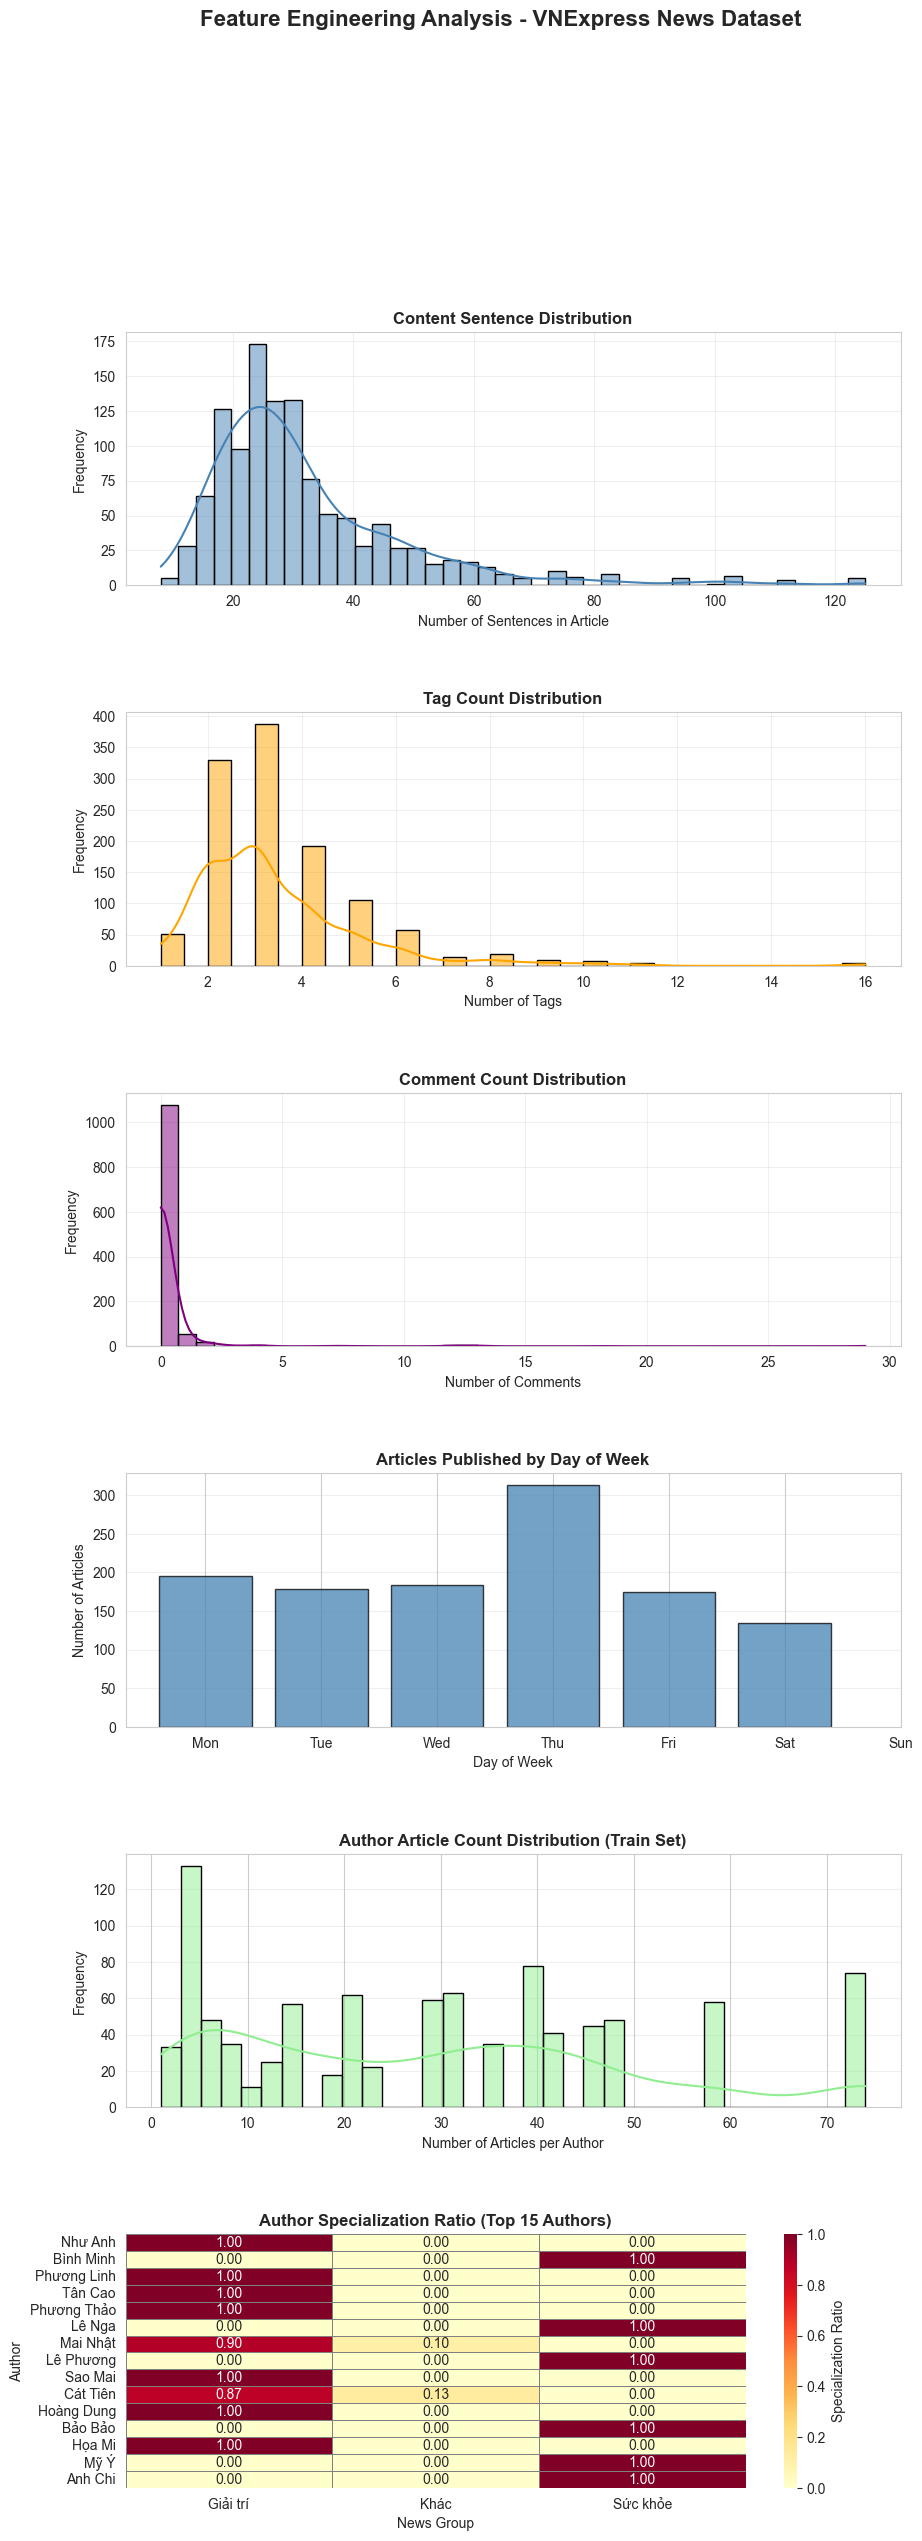


✓ Visualization Complete!


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

fig = plt.figure(figsize=(10, 28))
gs = fig.add_gridspec(6, 1, hspace=0.5)

# =========================================================
# 1. CONTENT SENTENCE DISTRIBUTION
# =========================================================

ax1 = fig.add_subplot(gs[0, 0])

sns.histplot(
    df["content_sentences"],
    bins=40,
    kde=True,
    color="steelblue",
    edgecolor="black",
    ax=ax1
)

ax1.set_title("Content Sentence Distribution", fontsize=12, fontweight='bold')
ax1.set_xlabel("Number of Sentences in Article")
ax1.set_ylabel("Frequency")
ax1.grid(alpha=0.3)

# =========================================================
# 2. TAG DISTRIBUTION
# =========================================================

ax2 = fig.add_subplot(gs[1, 0])

sns.histplot(
    df["num_tags"],
    bins=30,
    kde=True,
    color="orange",
    edgecolor="black",
    ax=ax2
)

ax2.set_title("Tag Count Distribution", fontsize=12, fontweight='bold')
ax2.set_xlabel("Number of Tags")
ax2.set_ylabel("Frequency")
ax2.grid(alpha=0.3)

# =========================================================
# 3. COMMENT DISTRIBUTION
# =========================================================

ax3 = fig.add_subplot(gs[2, 0])

sns.histplot(
    df["nums_of_comments"],
    bins=40,
    kde=True,
    color="purple",
    edgecolor="black",
    ax=ax3
)

ax3.set_title("Comment Count Distribution", fontsize=12, fontweight='bold')
ax3.set_xlabel("Number of Comments")
ax3.set_ylabel("Frequency")
ax3.grid(alpha=0.3)

# =========================================================
# 4. ARTICLES BY DAY OF WEEK
# =========================================================

ax4 = fig.add_subplot(gs[3, 0])

day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
day_counts = df["day_of_week"].value_counts().sort_index()

ax4.bar(
    range(len(day_counts)),
    day_counts.values,
    color="steelblue",
    edgecolor="black",
    alpha=0.75
)

ax4.set_xticks(range(7))
ax4.set_xticklabels(day_labels)

ax4.set_title("Articles Published by Day of Week", fontsize=12, fontweight='bold')
ax4.set_xlabel("Day of Week")
ax4.set_ylabel("Number of Articles")

ax4.grid(axis='y', alpha=0.3)

# =========================================================
# 5. AUTHOR ARTICLE COUNT
# =========================================================

ax5 = fig.add_subplot(gs[4, 0])

sns.histplot(
    X_train["author_article_count"],
    bins=35,
    kde=True,
    color="lightgreen",
    edgecolor="black",
    ax=ax5
)

ax5.set_title("Author Article Count Distribution (Train Set)", fontsize=12, fontweight='bold')
ax5.set_xlabel("Number of Articles per Author")
ax5.set_ylabel("Frequency")

ax5.grid(axis='y', alpha=0.3)

# =========================================================
# 6. AUTHOR SPECIALIZATION HEATMAP
# =========================================================

ax6 = fig.add_subplot(gs[5, 0])

top_authors = author_counts.head(15).index

sns.heatmap(
    author_group_ratio.loc[top_authors],
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Specialization Ratio'},
    ax=ax6
)

ax6.set_title("Author Specialization Ratio (Top 15 Authors)", fontsize=12, fontweight='bold')
ax6.set_xlabel("News Group")
ax6.set_ylabel("Author")

# =========================================================
# GLOBAL TITLE
# =========================================================

plt.suptitle(
    "Feature Engineering Analysis - VNExpress News Dataset",
    fontsize=16,
    fontweight='bold',
    y=0.995
)

plt.tight_layout()
plt.show()

print("\n✓ Visualization Complete!")